In [81]:
import pandas as pd

# Load the Dataset

In [82]:
# Load the CSV file into a DataFrame
df = pd.read_csv('housing.csv')

# Display the first 5 rows of the DataFrame
print(df.head())
print('\n')
# Display the first 5 rows of the DataFrame
print(df.tail())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


       longitude  latitude  housing_median_age  total_rooms  total_bedroo

# Understand the Data Structure

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [84]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

# Check Missing Values

In [85]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

# Replace Missing Values

In [86]:
df["total_bedrooms"]=df["total_bedrooms"].fillna(df["total_bedrooms"].median())

# Checking duplicated values

In [87]:
df.duplicated().sum()

np.int64(0)

# there are no duplicaes

# Detect outliers

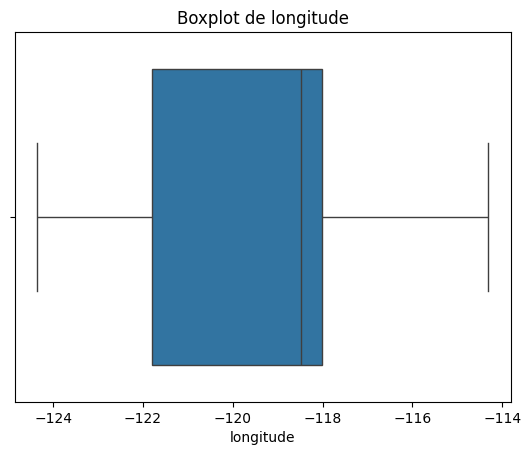

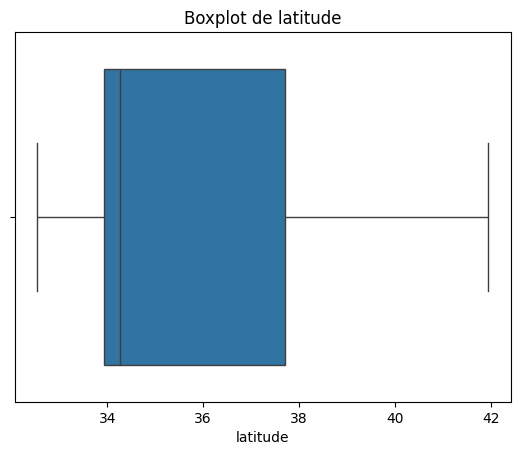

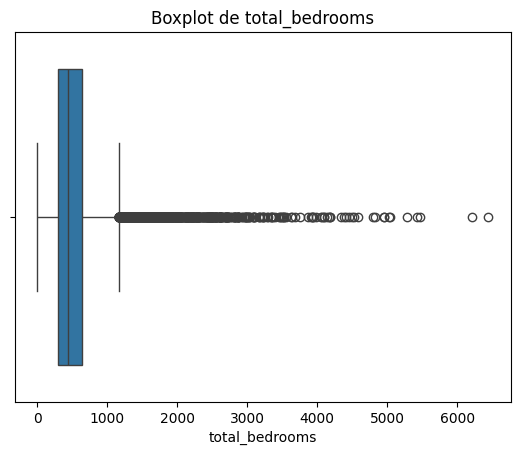

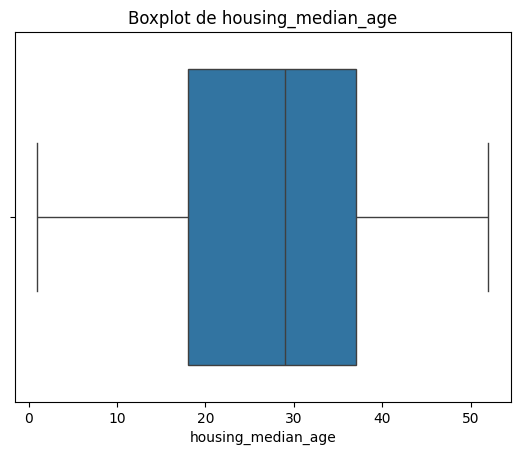

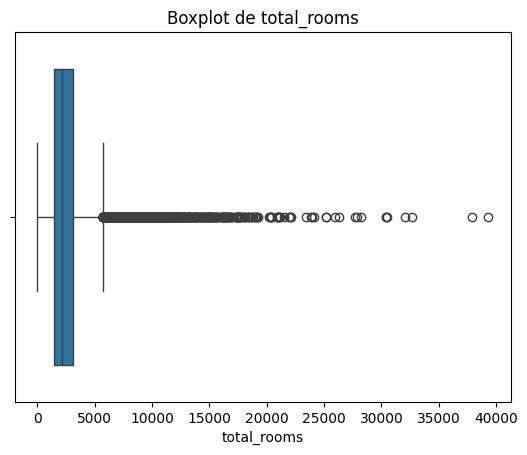

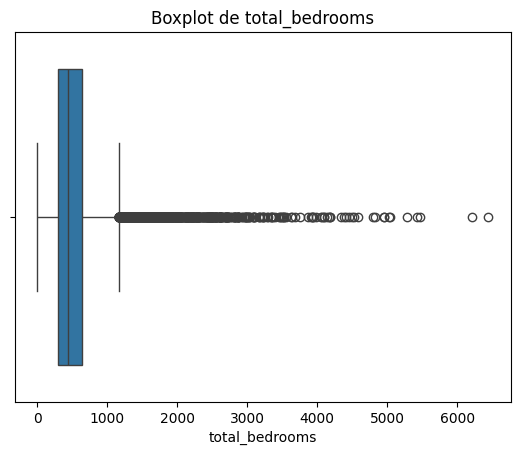

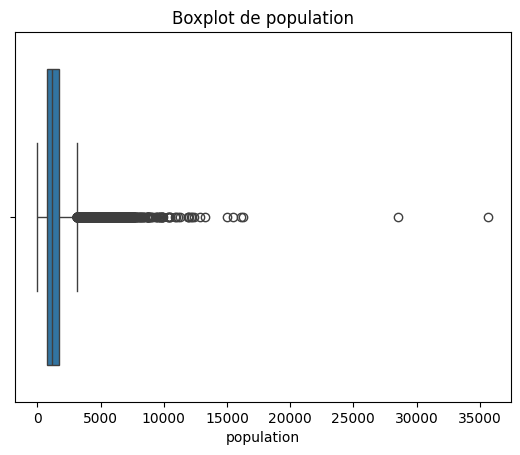

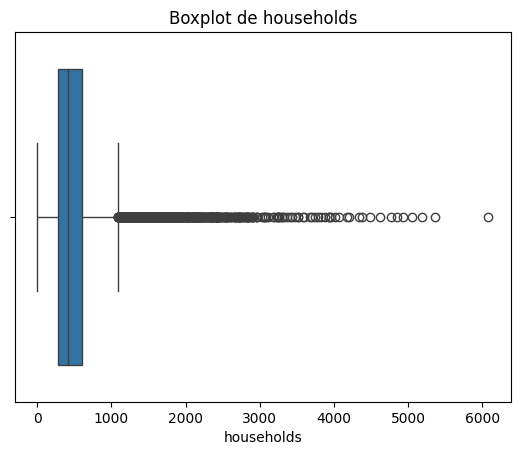

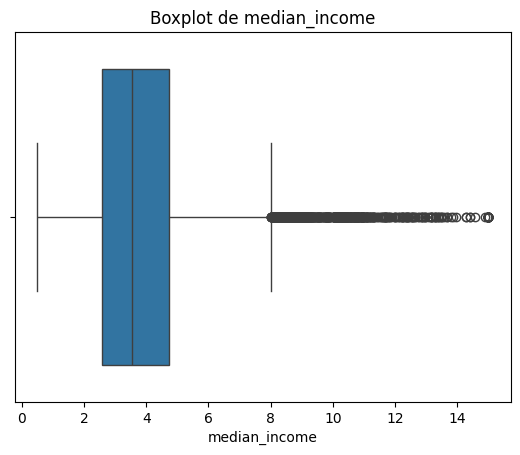

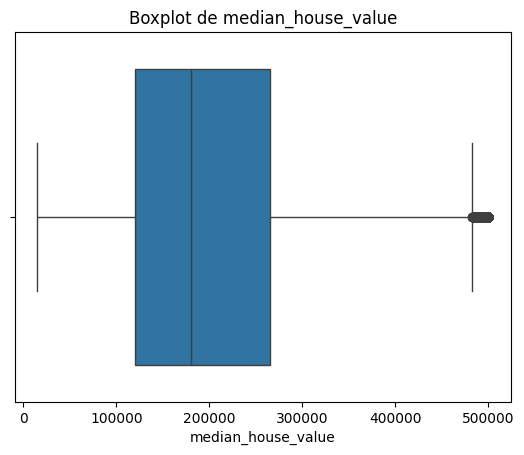

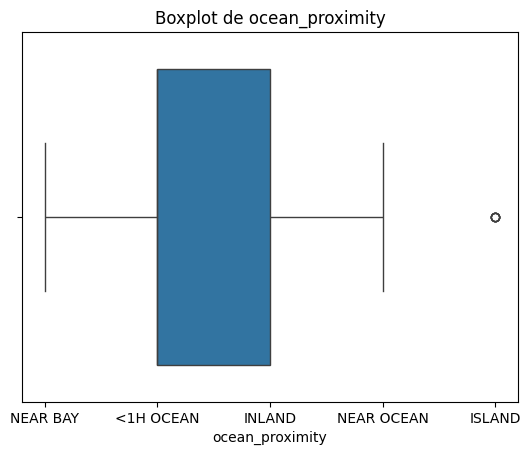

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
cols =["longitude", "latitude","total_bedrooms","housing_median_age","total_rooms","total_bedrooms","population","households","median_income","median_house_value","ocean_proximity"]

for col in cols :
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title("Boxplot de "+col)
    plt.show()
    plt.close()

# Treat Detected outliers

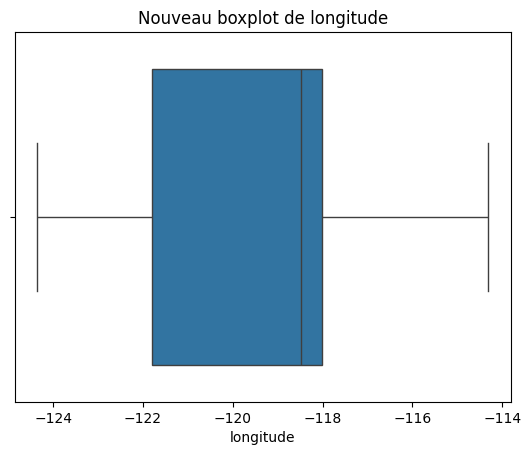

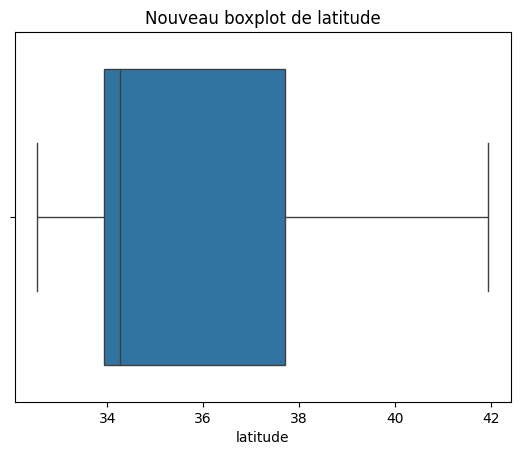

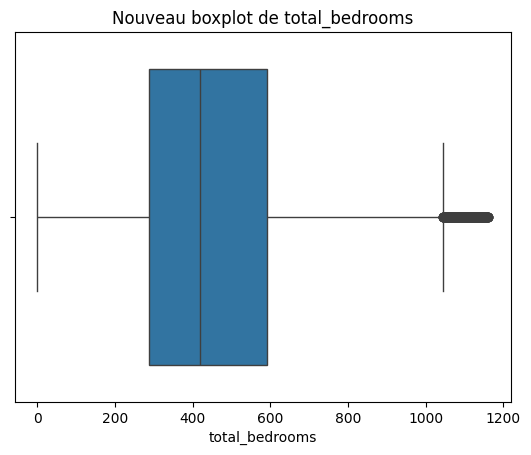

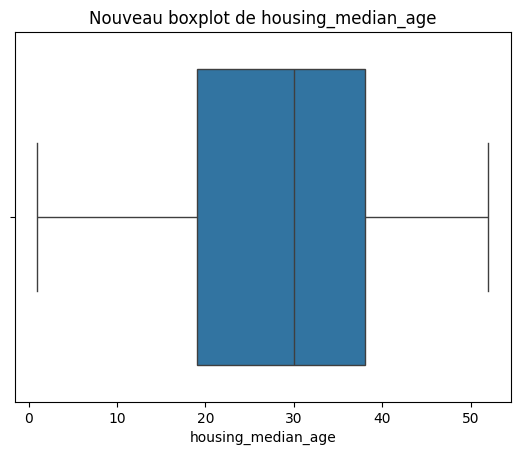

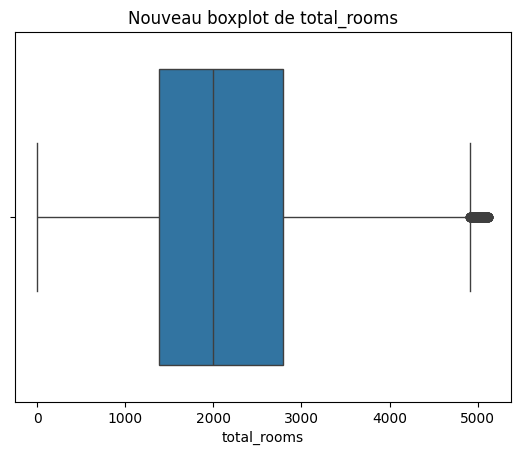

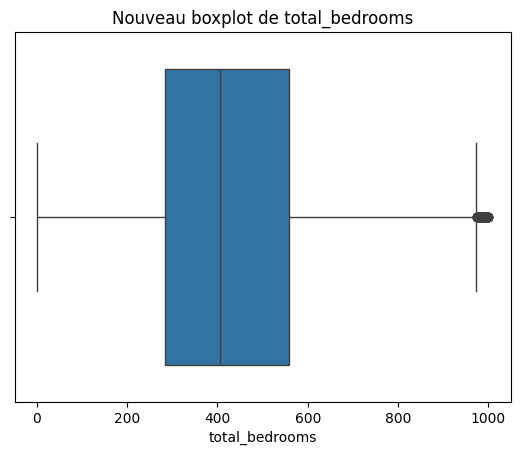

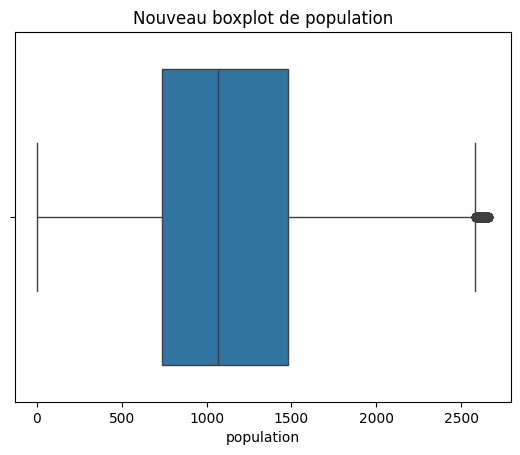

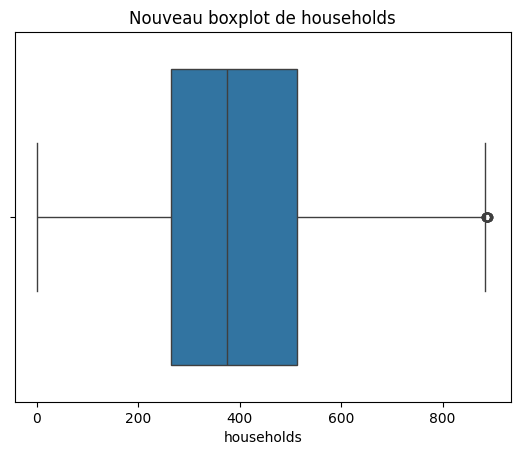

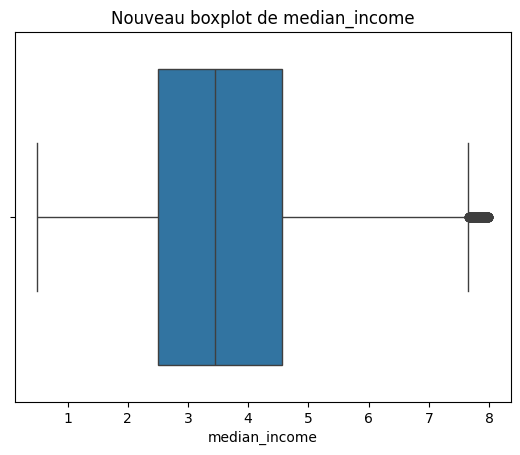

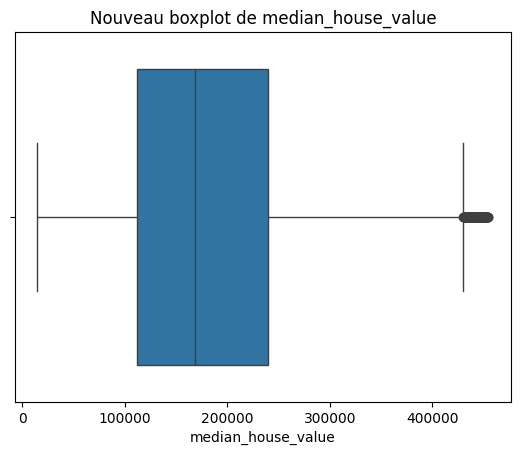

In [89]:
import seaborn as sns
cols =["longitude", "latitude","total_bedrooms","housing_median_age","total_rooms","total_bedrooms","population","households","median_income","median_house_value"]
for col in cols :

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title("Nouveau boxplot de "+ col)
    plt.show()
    plt.close()


# Remarque
ISLAND est une catégorie légitime de la variable ocean_proximity. Dans le contexte des variables catégorielles, on ne parle pas d'outliers mais plutôt de catégories rares. Même si ISLAND a peu d'exemples, c'est toujours une valeur valide !

# Vérifier à nouveau les valeurs manquantes et dupliquees

In [90]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [91]:
df.duplicated().sum()

np.int64(0)

# Comprendre la distribution des catégories Le nettoyage de colonne ocean_proximity

In [92]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7151
INLAND        5647
NEAR OCEAN    2095
NEAR BAY      1785
ISLAND           5
Name: count, dtype: int64

In [93]:
df['ocean_proximity'] = df['ocean_proximity'].str.lower()
df['ocean_proximity'].value_counts()

ocean_proximity
<1h ocean     7151
inland        5647
near ocean    2095
near bay      1785
island           5
Name: count, dtype: int64

In [94]:
# supprimer les espaces en debut et fin de chaine de toutes les valeurs de la colonne
df['ocean_proximity']=df['ocean_proximity'].str.strip()
df['ocean_proximity'].value_counts()

ocean_proximity
<1h ocean     7151
inland        5647
near ocean    2095
near bay      1785
island           5
Name: count, dtype: int64

In [95]:
# corriger les fautes de frappe potentienlles
correction_map = {
    "inland ": "inland",       # Corrige l'espace à la fin
    "NEAR OCEAN": "near ocean", # Uniformise la casse
    "INLAND": "inland",
    "<1h ocean": "<1h ocean"    # Si on veut garder cette forme, pas de changement
}

df['ocean_proximity']=df['ocean_proximity'].replace(correction_map)
print("\nAprès correction des erreurs (exemple) :")
print(df['ocean_proximity'].value_counts())


Après correction des erreurs (exemple) :
ocean_proximity
<1h ocean     7151
inland        5647
near ocean    2095
near bay      1785
island           5
Name: count, dtype: int64


# Enregistrer le csv nettoye

In [96]:
df.to_csv("housing_cleaned.csv", index=False)